total de linhas de apenas: (324653, 69)
------------------------------------------------------------
qtde de inscritos:


,situacao_fies,qtde_inscritos
0,CONTRATADA,7315
1,INSCRIÇÃO POSTERGADA,380
2,LISTA DE ESPERA,287584
3,NÃO CONTRATADO,16431
4,OPÇÃO NÃO CONTRATADA,2871
5,PARTICIPACAO CANCELADA PELO CANDIDATO,8870
6,PRÉ-SELECIONADO,609
7,REJEITADA PELA CPSA,593


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                            0
gap                                                                                                                         1
idade                                                                                                                       0
nota_corte_gp                                                                                                               0
renda_gap                                                                                                                   1
beneficiado_creduc_fies_NÃO                                                                                                 0
beneficiado_creduc_fies_SIM                                                                                                 0
modalidade_fies_Modalidade II                                                   

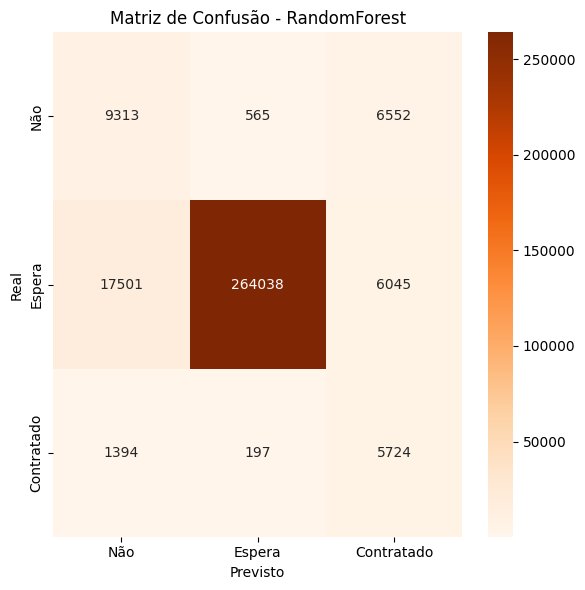

Distribuição prevista: 1.0    0.850547
0.0    0.090605
2.0    0.058848
Name: proportion, dtype: float64
Distribuição real: status
1.0    0.923730
0.0    0.052774
2.0    0.023496
Name: proportion, dtype: float64
Top variáveis mais importantes:


,Variavel,Importancia
0,gap,0.426662
1,renda_gap,0.313097
2,nota_corte_gp,0.049596
3,opcao_curso_2,0.038918
4,concluiu_curso_superior_SIM,0.036073
5,ensino_medio_escola_publica_SIM,0.034677
6,opcao_curso_3,0.022310
7,renda_per_capita,0.020000
8,idade,0.013805
9,conceito_curso_gp_4,0.007024


Todas as importâncias:


,Variavel,Importancia
0,gap,0.426662
1,renda_gap,0.313097
2,nota_corte_gp,0.049596
3,opcao_curso_2,0.038918
4,concluiu_curso_superior_SIM,0.036073
5,ensino_medio_escola_publica_SIM,0.034677
6,opcao_curso_3,0.022310
7,renda_per_capita,0.020000
8,idade,0.013805
9,conceito_curso_gp_4,0.007024


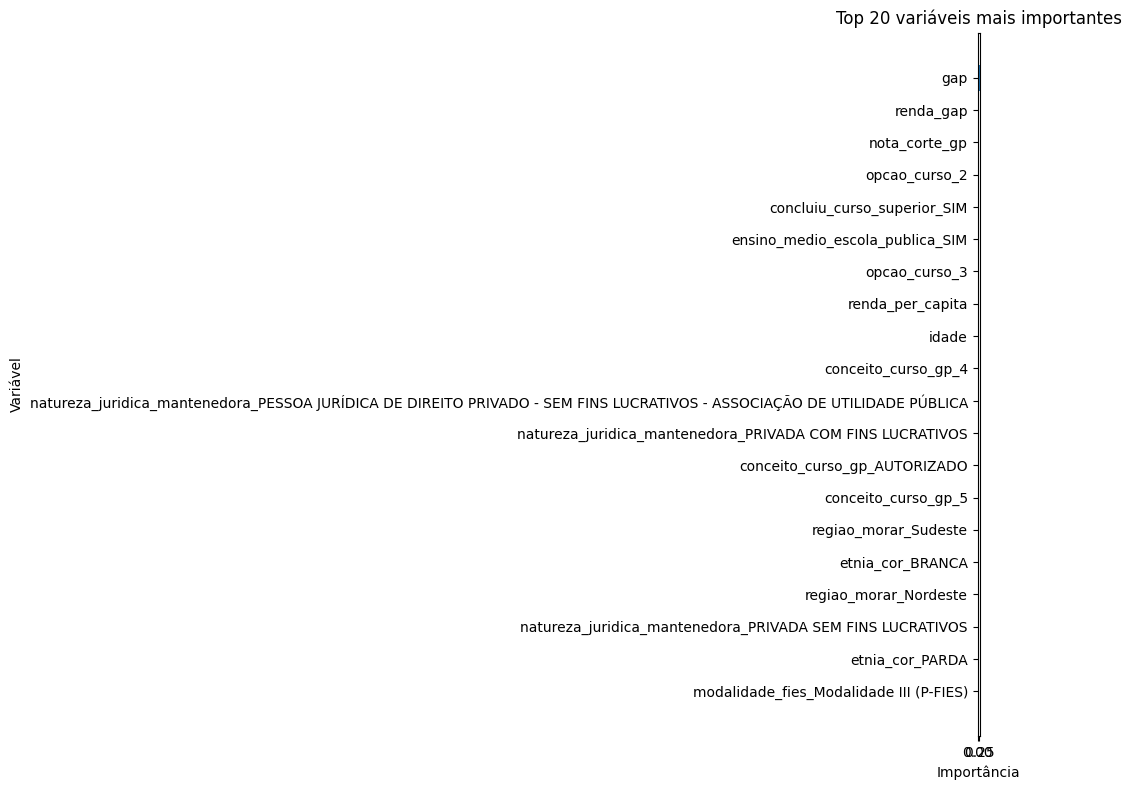


[INFO] Gráfico 1: impacto da NOTA dependendo da RENDA
[INFO] Cada linha fixa uma renda e mostra como a probabilidade varia com o gap
[INFO] Linha azul (0.5 = 50%) é o limiar de decisão do modelo


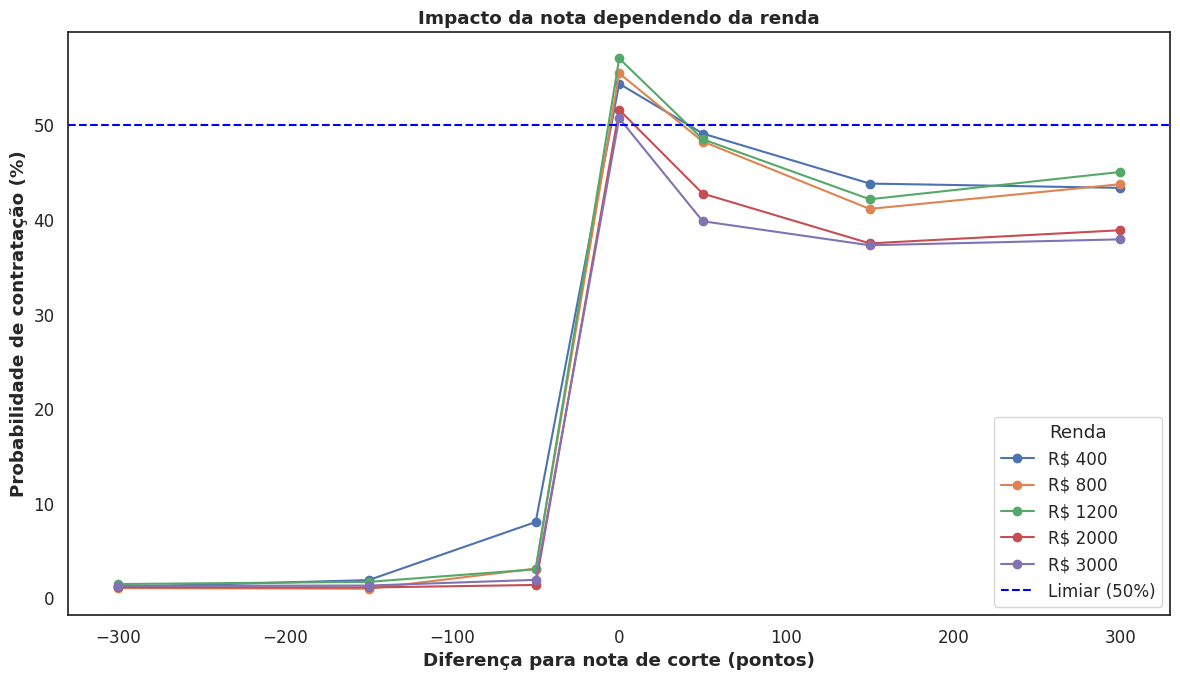


[INFO] Gráfico 2: impacto da RENDA dependendo da NOTA
[INFO] Cada linha fixa um gap e mostra como a probabilidade varia com a renda


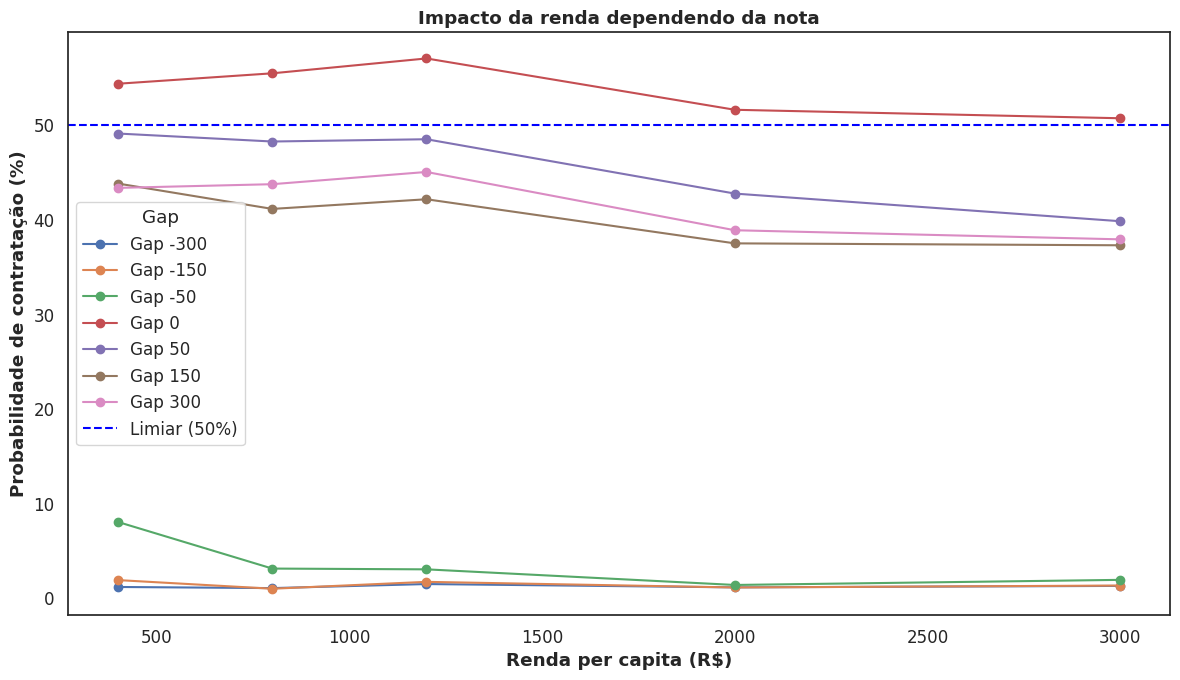


[INFO] Heatmap: visão consolidada renda × nota


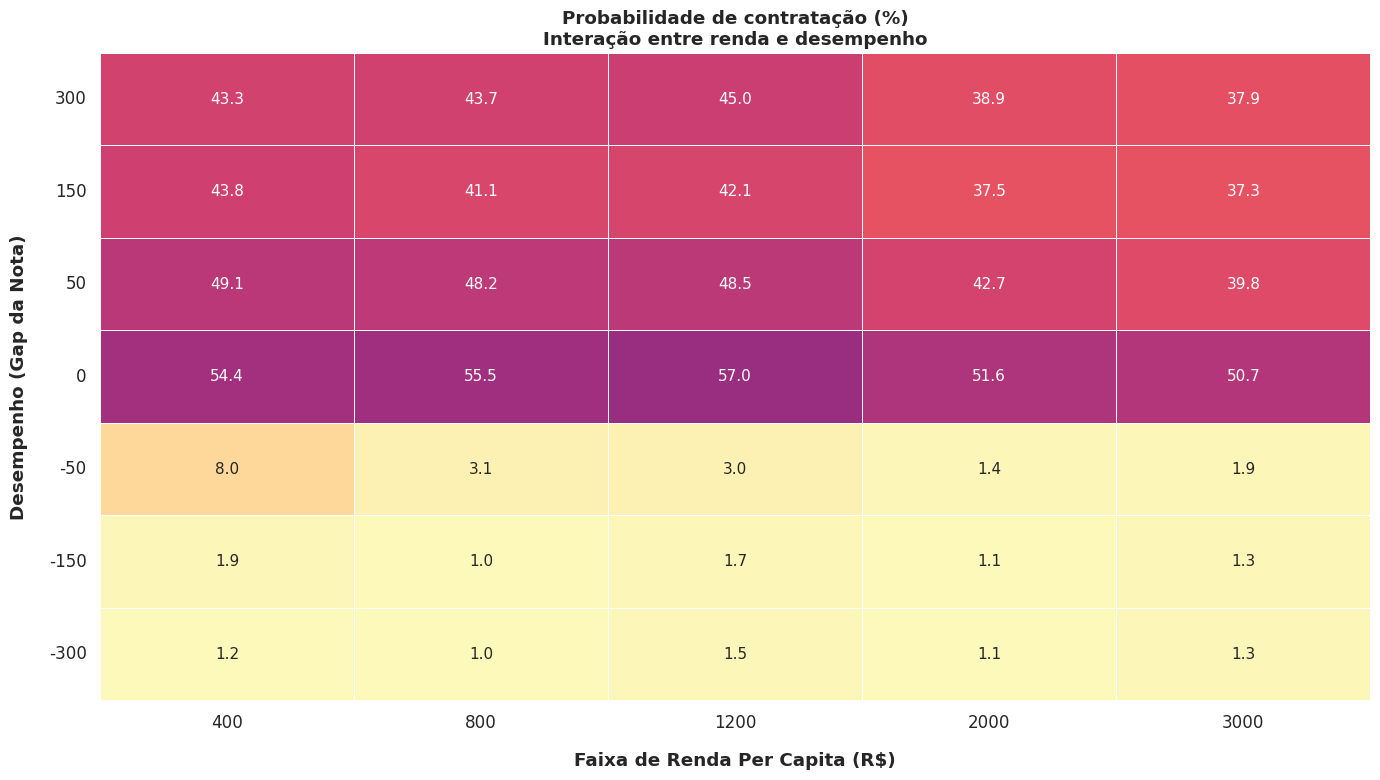


🧠 INTERPRETAÇÃO COMPLETA — RANDOM FOREST (ANÁLISE 017)

📊 IMPORTÂNCIA DAS VARIÁVEIS (TOP 10):
                           variavel  importancia
1                               gap     0.426662
4                         renda_gap     0.313097
3                     nota_corte_gp     0.049596
10                    opcao_curso_2     0.038918
12      concluiu_curso_superior_SIM     0.036073
34  ensino_medio_escola_publica_SIM     0.034677
11                    opcao_curso_3     0.022310
0                  renda_per_capita     0.020000
2                             idade     0.013805
13              conceito_curso_gp_4     0.007024

🔎 FOCO NAS VARIÁVEIS-CHAVE:
 - renda_per_capita: 0.0200
 - gap:              0.4267
 - renda_gap:        0.3131

📌 INTERPRETAÇÃO DAS IMPORTÂNCIAS:

- A Random Forest NÃO usa coeficientes lineares.
- Aqui, a "importância" mede o quanto cada variável ajuda a reduzir erro nas árvores.

👉 Quanto maior a importância:
   MAIS o modelo depende daquela variável para deci

In [ ]:
# fazer roc auc
# testar o msm modelo reg logit, mas com o dataset inteiro na matriz de confusao sem distinguir anos e semestre

import pandas as pd
from constantes import pasta_data_04_load_inscritos,pasta_data_05_processed_analise_017
from sklearn.linear_model import LogisticRegression

# Configuração de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. CARREGAR OS DADOS
df_raiz = pd.read_parquet(str(pasta_data_04_load_inscritos))

filtro_treino_base = (df_raiz['subarea_conhecimento'] == 'MEDICINA')

df_base = df_raiz[filtro_treino_base].copy()

# 2. CRIAR VARIÁVEIS NOVAS (Vetorizado, muito mais rápido)
df_base['gap'] = df_base['media_enem'] - df_base['nota_corte_gp']

def idade(x):
    try:
        return 2026 - int(str(x).split('/')[-1])
    except:
        return None

df_base['idade'] = df_base['data_nascimento'].apply(idade)



print('total de linhas de apenas:', df_base.shape)



print('-'*60)
print('qtde de inscritos:')
display(df_base.groupby('situacao_fies',as_index=False).size().rename(columns={'size':'qtde_inscritos'}))#type: ignore





# 3. DUMIZAR VARIÁVEIS CATEGÓRICAS
# Isso cria as colunas 0 e 1 e JÁ EXCLUI a 'nome_cine_area_geral' original
df = pd.get_dummies(df_base, columns=['beneficiado_creduc_fies','modalidade_fies','subarea_conhecimento','regiao_morar','natureza_juridica_mantenedora','etnia_cor','turno','ensino_medio_escola_publica','conceito_curso_gp','concluiu_curso_superior','opcao_curso'], drop_first=True)

# 4. FILTRAR A BASE DE DADOS
    # 2. Mapear cada situação para número
def mapear_status(x):
    if x == 'CONTRATADA':
        return 2
    elif x == 'LISTA DE ESPERA':
        return 1
    elif x == 'NÃO CONTRATADO':
        return 0
    else:
        return None

df['status'] = df['situacao_fies'].apply(mapear_status)


# 6. PESCAR AS COLUNAS DUMMIES
# O Python procura e guarda apenas as colunas que começam com esse nome
colunas_dummies_turno = [col for col in df.columns if col.startswith('turno_')]

colunas_dummies_ensino_medio_escola_publica = [col for col in df.columns if col.startswith('ensino_medio_escola_publica_')]
colunas_dummies_etnia = [col for col in df.columns if col.startswith('etnia_cor_')]
colunas_dummies_cine = [col for col in df.columns if col.startswith('subarea_conhecimento_')]
colunas_dummies_regiao = [col for col in df.columns if col.startswith('regiao_morar_')]
colunas_dummies_natureza = [col for col in df.columns if col.startswith('natureza_juridica_mantenedora_')]
colunas_dummies_opcao_curso = [col for col in df.columns if col.startswith('opcao_curso')]
colunas_dummies_conceito_curso = [col for col in df.columns if col.startswith('conceito_curso_gp')]
colunas_dummies_conceito_concluiu_curso_superior = [col for col in df.columns if col.startswith('concluiu_curso_superior')]
colunas_dummies_conceito_concluiu_modfies = [col for col in df.columns if col.startswith('modalidade_fies')]
colunas_dummies_conceito_concluiu_BENEFcreduc = [col for col in df.columns if col.startswith('beneficiado_creduc_fies')]






# 9. CRIAR A LISTA EXATA DE FEATURES
# Juntamos as variáveis que você escolheu com as dummies
df['renda_gap']=df['renda_per_capita'] * df['gap']


features_exatas = ['renda_per_capita', 'gap','idade','nota_corte_gp','renda_gap']+ colunas_dummies_conceito_concluiu_BENEFcreduc + colunas_dummies_conceito_concluiu_modfies + colunas_dummies_opcao_curso + colunas_dummies_conceito_concluiu_curso_superior + colunas_dummies_conceito_curso + colunas_dummies_cine + colunas_dummies_regiao + colunas_dummies_natureza + colunas_dummies_etnia + colunas_dummies_turno + colunas_dummies_ensino_medio_escola_publica



# Faz o Raio-X apenas nas colunas que vão pro modelo
print("--- Quantidade de NaNs por coluna ---")
print(df[features_exatas].isna().sum())

# Isso garante que se o aluno sumir, ele some das duas listas
# =========================================================
# LIMPEZA CORRETA (X e Y juntos)
# =========================================================

df_limpo = df.dropna(subset=features_exatas + ['status']).copy()

# agora sim, tudo alinhado
X = df_limpo[features_exatas]
Y = df_limpo['status']

# usar a mesma base pra treino/teste (como você quer)
X_treino = X.copy()
Y_treino = Y.copy()

X_teste = X.copy()
y_teste = Y.copy()



print('coluna x linha do X com NaN inclusos:',X.shape)

print('coluna x linha do X sem NaN inclusos:',X.shape)

print('-'*60)
print(f"Registros de Treino: {len(X):,}")
print(f"Registros de Teste: {len(X_teste):,}")

# RANDOM FOREST — classificação binária
# Base inteira 2019 a 2021
# Objetivo: captar não linearidade e interação entre renda_per_capita e gap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import plot_tree, export_text
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from constantes import (
    pasta_data_04_load_inscritos
)

# =========================================================
# 1) CARREGAR DADOS
# =========================================================



# usando a base inteira na avaliação
X_treino = X.copy()
Y_treino = Y.copy()
X_teste = X.copy()
y_teste = Y.copy()

# =========================================================
# 2) TREINAR MODELO
# =========================================================

max_depth = 42

modelo = RandomForestClassifier(
    max_depth=max_depth,
    n_estimators=1000,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42,
    min_samples_leaf=125,
    max_features='sqrt'
)

modelo.fit(X_treino, Y_treino)

print("Modelo RandomForest treinado com sucesso.")

# =========================================================
# 3) VISUALIZAR UMA ÁRVORE DA FLORESTA (OPCIONAL)
# =========================================================

visualizar_arvore = 'nao'

if visualizar_arvore == 'sim':
    arvore = modelo.estimators_[0]

    plt.figure(figsize=(40, 20))
    plot_tree(
        arvore,
        feature_names=list(X_treino.columns),
        class_names=['Não Contratado', 'Lista Espera', 'Contratado'],  # 🔥 corrigido
        filled=True,
        rounded=True,
        fontsize=8,
        max_depth=3
    )
    plt.show()

    regras_arvore = export_text(
        arvore,
        feature_names=list(X_treino.columns),
        max_depth=3
    )
    print(regras_arvore)

# =========================================================
# 4) AVALIAÇÃO NA MESMA BASE (MULTICLASSE CORRETA)
# =========================================================

# previsão final (classe)
y_predict = modelo.predict(X_teste)

# probabilidades (todas as classes)
y_probs = modelo.predict_proba(X_teste)

# ROC AUC multiclasse
roc = roc_auc_score(
    y_teste,
    y_probs,
    multi_class='ovr',
    labels=modelo.classes_
)
# acurácia
acuracia = accuracy_score(y_teste, y_predict)

print(f"Acurácia da RandomForest: {acuracia:.4f}")
print(f"ROC-AUC (ovr): {roc:.4f}")

print("\n=== Relatório de Classificação ===")
print(classification_report(y_teste, y_predict))

# matriz de confusão (agora 3x3)
matriz = confusion_matrix(y_teste, y_predict)

plt.figure(figsize=(6, 6))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Não', 'Espera', 'Contratado'],   # 🔥 importante
    yticklabels=['Não', 'Espera', 'Contratado']
)
plt.title("Matriz de Confusão - RandomForest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# distribuição das previsões
print(f"Distribuição prevista: {pd.Series(y_predict).value_counts(normalize=True)}")
print(f"Distribuição real: {pd.Series(y_teste).value_counts(normalize=True)}")

# =========================================================
# 5) IMPORTÂNCIA DAS VARIÁVEIS
# =========================================================

df_importancias = pd.DataFrame({
    'Variavel': X_treino.columns,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

print("Top variáveis mais importantes:")
display(df_importancias.head(30))

print("Todas as importâncias:")
display(df_importancias)

plt.figure(figsize=(10, 8))
top20 = df_importancias.head(20).sort_values("Importancia")
plt.barh(top20["Variavel"], top20["Importancia"])
plt.title("Top 20 variáveis mais importantes")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

# =========================================================
# 6) LEITURA DE INTERAÇÃO RENDA × GAP
# =========================================================

def analise_real_renda_gap_rf(modelo, X_ref):
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ==============================================================================
    # 1. CONFIGURAÇÕES (PADRÃO VISUAL)
    # ==============================================================================

    sns.set_theme(style="white", font_scale=1.1)

    pasta_figuras = Path('reports/figures/analise_017').resolve()
    pasta_figuras.mkdir(parents=True, exist_ok=True)

    # ==============================================================================
    # 2. GRID CONTROLADO (INTERPRETÁVEL)
    # ==============================================================================

    rendas = [400, 800, 1200, 2000, 3000]
    gaps = [-300, -150, -50, 0, 50, 150, 300]

    valores_medios = X_ref.mean(numeric_only=True)
    mediana_idade = X_ref['idade'].median()
    mediana_nota_corte = X_ref['nota_corte_gp'].median()

    linhas = []

    for renda in rendas:
        for gap in gaps:

            linha = {}

            for col in X_ref.columns:
                if col == 'renda_per_capita':
                    linha[col] = renda
                elif col == 'gap':
                    linha[col] = gap
                elif col == 'renda_gap':
                    linha[col] = renda * gap
                elif col == 'idade':
                    linha[col] = mediana_idade
                elif col == 'nota_corte_gp':
                    linha[col] = mediana_nota_corte
                else:
                    linha[col] = valores_medios.get(col, 0)

            linhas.append(linha)

    df_real = pd.DataFrame(linhas).reindex(columns=X_ref.columns, fill_value=0)

    # ==============================================================================
    # 3. PREDIÇÃO
    # ==============================================================================

    probs = modelo.predict_proba(df_real)

    # índice da classe "2" (CONTRATADO)
    idx_contratado = list(modelo.classes_).index(2)

    df_real['prob'] = probs[:, idx_contratado] * 100  # 🔥 prob de contratação

    # ==============================================================================
    # 4. CURVAS — IMPACTO DA NOTA DEPENDENDO DA RENDA
    # ==============================================================================

    print("\n[INFO] Gráfico 1: impacto da NOTA dependendo da RENDA")
    print("[INFO] Cada linha fixa uma renda e mostra como a probabilidade varia com o gap")
    print("[INFO] Linha azul (0.5 = 50%) é o limiar de decisão do modelo")

    plt.figure(figsize=(12, 7))

    for renda in rendas:
        subset = df_real[df_real['renda_per_capita'] == renda].sort_values('gap')

        plt.plot(
            subset['gap'],
            subset['prob'],
            marker='o',
            label=f'R$ {renda}'
        )

    plt.axhline(50, color='blue', linestyle='--', label='Limiar (50%)')

    plt.xlabel('Diferença para nota de corte (pontos)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da nota dependendo da renda', fontweight='bold')

    plt.legend(title='Renda')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_curvas_nota_por_renda.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 5. CURVAS — IMPACTO DA RENDA DEPENDENDO DA NOTA
    # ==============================================================================

    print("\n[INFO] Gráfico 2: impacto da RENDA dependendo da NOTA")
    print("[INFO] Cada linha fixa um gap e mostra como a probabilidade varia com a renda")

    plt.figure(figsize=(12, 7))

    for gap in gaps:
        subset = df_real[df_real['gap'] == gap].sort_values('renda_per_capita')

        plt.plot(
            subset['renda_per_capita'],
            subset['prob'],
            marker='o',
            label=f'Gap {gap}'
        )

    plt.axhline(50, color='blue', linestyle='--', label='Limiar (50%)')

    plt.xlabel('Renda per capita (R$)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da renda dependendo da nota', fontweight='bold')

    plt.legend(title='Gap')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_curvas_renda_por_nota.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 6. HEATMAP — PADRÃO ABNT (RENDA × NOTA)
    # ==============================================================================

    print("\n[INFO] Heatmap: visão consolidada renda × nota")

    ordem_gap = gaps[::-1]  # 🔥 alto desempenho em cima

    matriz = df_real.pivot(
        index='gap',
        columns='renda_per_capita',
        values='prob'
    ).reindex(index=ordem_gap, columns=rendas)

    plt.figure(figsize=(14, 8))

    sns.heatmap(
        matriz,
        annot=True,
        fmt=".1f",
        cmap="magma_r",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 11},
        cbar=False
    )

    plt.ylabel('Desempenho (Gap da Nota)', fontweight='bold', labelpad=15)
    plt.xlabel('Faixa de Renda Per Capita (R$)', fontweight='bold', labelpad=15)

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title(
        'Probabilidade de contratação (%)\nInteração entre renda e desempenho',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_heatmap_renda_nota.png', dpi=300, bbox_inches='tight')
    plt.show()

analise_real_renda_gap_rf(modelo, X_treino)


# =========================================================
# 8) INTERPRETAÇÃO COMPLETA DO MODELO (PRINT EXPLICATIVO)
# =========================================================

def interpretacao_modelo_random_forest(modelo, X):

    import pandas as pd
    import numpy as np

    print("\n" + "="*80)
    print("🧠 INTERPRETAÇÃO COMPLETA — RANDOM FOREST (ANÁLISE 017)")
    print("="*80)

    # =====================================================
    # 1. IMPORTÂNCIAS DAS VARIÁVEIS
    # =====================================================

    df_imp = pd.DataFrame({
        'variavel': X.columns,
        'importancia': modelo.feature_importances_
    }).sort_values(by='importancia', ascending=False)

    print("\n📊 IMPORTÂNCIA DAS VARIÁVEIS (TOP 10):")
    print(df_imp.head(10))

    # pegar principais
    imp_renda = df_imp[df_imp['variavel'] == 'renda_per_capita']['importancia'].values
    imp_gap = df_imp[df_imp['variavel'] == 'gap']['importancia'].values
    imp_inter = df_imp[df_imp['variavel'] == 'renda_gap']['importancia'].values

    imp_renda = imp_renda[0] if len(imp_renda) else 0
    imp_gap = imp_gap[0] if len(imp_gap) else 0
    imp_inter = imp_inter[0] if len(imp_inter) else 0

    print("\n🔎 FOCO NAS VARIÁVEIS-CHAVE:")
    print(f" - renda_per_capita: {imp_renda:.4f}")
    print(f" - gap:              {imp_gap:.4f}")
    print(f" - renda_gap:        {imp_inter:.4f}")

    # =====================================================
    # 2. INTERPRETAÇÃO DAS IMPORTÂNCIAS
    # =====================================================

    print("\n📌 INTERPRETAÇÃO DAS IMPORTÂNCIAS:")

    print("""
- A Random Forest NÃO usa coeficientes lineares.
- Aqui, a "importância" mede o quanto cada variável ajuda a reduzir erro nas árvores.

👉 Quanto maior a importância:
   MAIS o modelo depende daquela variável para decidir.
""")

    if imp_inter > imp_renda and imp_inter > imp_gap:
        print("🔥 PRINCIPAL DRIVER: INTERAÇÃO (renda × gap)")
    elif imp_gap > imp_renda:
        print("🔥 PRINCIPAL DRIVER: desempenho (gap)")
    else:
        print("🔥 PRINCIPAL DRIVER: renda")

    # =====================================================
    # 3. INTERPRETAÇÃO ECONÔMICA (O QUE O MODELO APRENDEU)
    # =====================================================

    print("\n📊 LEITURA ECONÔMICA DO MODELO:")

    print("""
    O modelo está aprendendo regras do tipo:

    - "Se renda é alta E nota é boa → alta chance de CONTRATAÇÃO"
    - "Se renda é baixa E nota ruim → alta chance de NÃO CONTRATAÇÃO"
    - "Se valores intermediários → maior chance de LISTA DE ESPERA"

    👉 Isso é NÃO-LINEARIDADE + INTERAÇÃO.

    👉 Importante:
    Agora o modelo NÃO decide apenas entre aprovado/reprovado,
    mas entre TRÊS estados:

    0 = Não contratado  
    1 = Lista de espera  
    2 = Contratado  

    Ou seja, ele aprende uma "zona intermediária" real do sistema.
    """)
    # =====================================================
    # 3.1 DISTRIBUIÇÃO DAS CLASSES PREVISTAS
    # =====================================================

    pred_classes = modelo.predict(X)

    print("\n📊 DISTRIBUIÇÃO DAS CLASSES PREVISTAS:")
    print(pd.Series(pred_classes).value_counts(normalize=True).sort_index())
    # =====================================================
    # 4. INTERPRETAÇÃO DOS GRÁFICOS
    # =====================================================

    print("\n📈 INTERPRETAÇÃO DOS GRÁFICOS GERADOS:")

    print("""
1) CURVAS (nota dependendo da renda):
   - Cada linha = uma renda fixa
   - Mostra como a nota (gap) impacta a chance

   👉 Se as curvas forem separadas:
      → renda altera o efeito da nota (INTERAÇÃO)

2) CURVAS (renda dependendo da nota):
   - Cada linha = um nível de desempenho
   - Mostra como renda impacta a chance

   👉 Se curvas não forem paralelas:
      → efeito da renda depende da nota

3) HEATMAP:
   - Visão mais importante
   - Cada célula = probabilidade do modelo

   👉 Leitura correta:
      - canto superior direito = melhor cenário
      - canto inferior esquerdo = pior cenário

   👉 Se o gradiente for diagonal:
      → modelo depende dos DOIS (renda + nota)

   👉 Se for mais horizontal:
      → gap domina

   👉 Se for mais vertical:
      → renda domina
""")

    # =====================================================
    # 5. DIFERENÇA PRA REGRESSÃO LOGÍSTICA
    # =====================================================

    print("\n⚖️ RANDOM FOREST vs REGRESSÃO LOGÍSTICA:")

    print("""
REGRESSÃO LOGÍSTICA:
- Linear
- Interpretação via coeficiente
- Interação explícita (renda_gap)

RANDOM FOREST:
- Não linear
- Interação automática
- Capta regras complexas tipo:
    "se renda > X E gap > Y então..."

👉 Ou seja:
RF é mais realista, mas menos interpretável direto.
""")

    # =====================================================
    # 6. CONCLUSÃO FINAL (NÍVEL EXECUTIVO)
    # =====================================================

    print("\n🏁 CONCLUSÃO FINAL:")

    print(f"""
- Importância renda: {imp_renda:.4f}
- Importância gap: {imp_gap:.4f}
- Importância interação: {imp_inter:.4f}

👉 O modelo indica que:

1. Existe efeito de RENDA
2. Existe efeito de DESEMPENHO (ENEM)
3. Existe INTERAÇÃO entre os dois

👉 Em termos reais:
A chance de contratação NÃO depende só da nota,
nem só da renda — depende da combinação dos dois.

👉 Isso confirma:
O sistema é NÃO linear e condicionado.
""")

    print("="*80)


# EXECUTAR
interpretacao_modelo_random_forest(modelo, X_treino)

# =========================================================
# 7) SALVAR MODELO (OPCIONAL)
# =========================================================
# import joblib
# from constantes import pasta_modelo_analise_017
# joblib.dump(modelo, str(pasta_modelo_analise_017))
# print(f"Modelo salvo em: {str(pasta_modelo_analise_017)}")